In [1]:
#!pip install datasets transformers sentencepiece accelerate scikit-learn seaborn tqdm

In [2]:
import numpy as np
import pandas as pd
import torch
import random

from pathlib import Path
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [4]:
DATASET = "Tobi-Bueck/customer-support-tickets"

ds = load_dataset(DATASET)["train"]
df = ds.to_pandas()

print("Dataset size:", len(df))
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Dataset size: 61765


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


Объединяем subject и body в одно поле. Заполняем пустые значения.

In [5]:
df["text"] = df["subject"].fillna("") + "\n\n" + df["body"].fillna("")
df["type"] = df["type"].fillna("Unknown")

In [6]:
def read_idx(path):
    return np.loadtxt(path, dtype=int)

train_idx = read_idx("train_idx.txt")
val_idx = read_idx("val_idx.txt")
test_idx = read_idx("test_idx.txt")

train = df.iloc[train_idx].reset_index(drop=True)
val = df.iloc[val_idx].reset_index(drop=True)
test = df.iloc[test_idx].reset_index(drop=True)

print(len(train), len(val), len(test))

49412 6176 6177


### EDA
Исследуем распределение классов, длины текстов, языки и дубликаты.

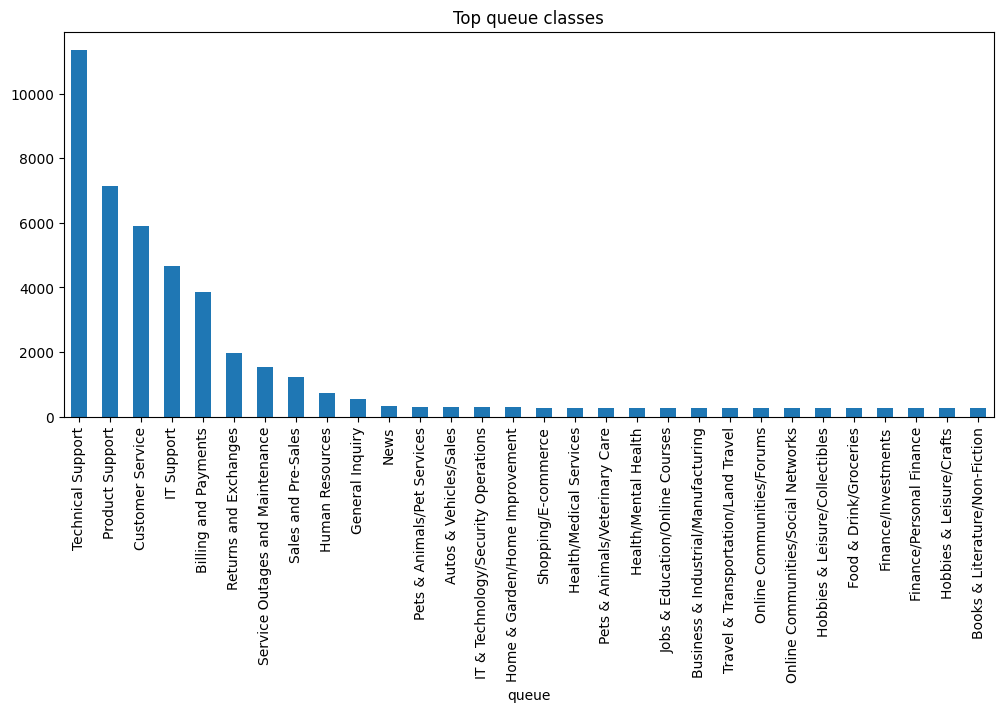

In [7]:
plt.figure(figsize=(12,5))
train["queue"].value_counts().head(30).plot.bar()
plt.title("Top queue classes")
plt.show()

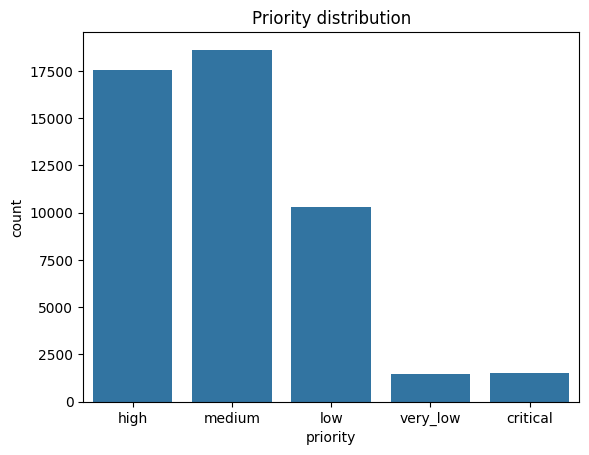

In [8]:
sns.countplot(data=train, x="priority")
plt.title("Priority distribution")
plt.show()

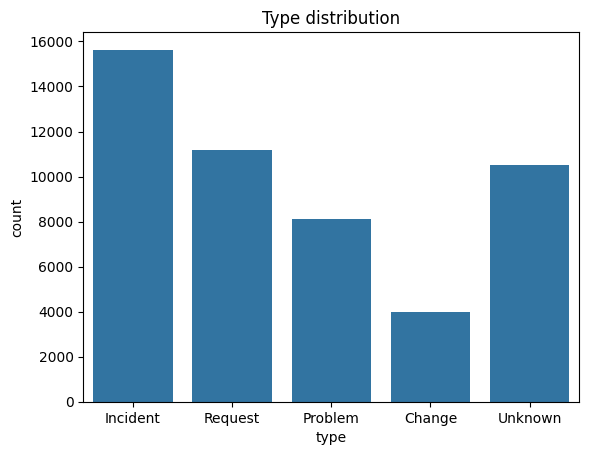

In [9]:
sns.countplot(data=train, x="type")
plt.title("Type distribution")
plt.show()

In [32]:
def text_stats(df, name=""):
    lens_chars = df["text"].str.len()
    lens_words = df["text"].str.split().map(len)

    print(f"{name}")
    print(f"Chars: mean={lens_chars.mean():.1f}, median={lens_chars.median()}, p90={lens_chars.quantile(0.9):.0f}, p99={lens_chars.quantile(0.99):.0f}")
    print(f"Words: mean={lens_words.mean():.1f}, median={lens_words.median()}, p90={lens_words.quantile(0.9):.0f}, p99={lens_words.quantile(0.99):.0f}")

text_stats(train, "Train")
text_stats(val, "Validation")
text_stats(test, "Test")

Train
Chars: mean=464.8, median=460.0, p90=755, p99=999
Words: mean=62.4, median=62.0, p90=99, p99=143
Validation
Chars: mean=466.7, median=463.0, p90=753, p99=1010
Words: mean=62.7, median=62.0, p90=98, p99=142
Test
Chars: mean=460.3, median=454.0, p90=751, p99=1015
Words: mean=62.1, median=62.0, p90=98, p99=147


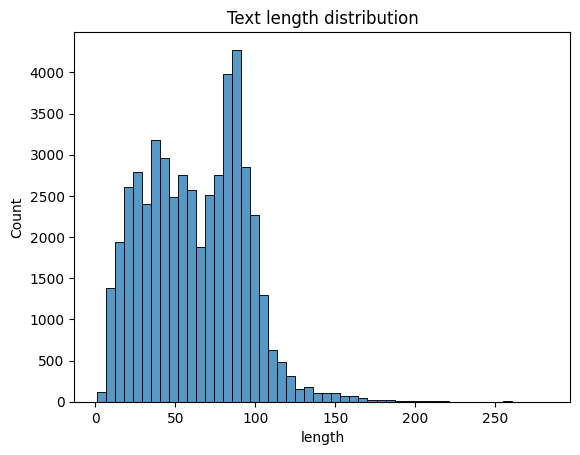

In [10]:
train["length"] = train["text"].str.split().apply(len)

sns.histplot(train["length"], bins=50)
plt.title("Text length distribution")
plt.show()

In [11]:
train["language"].value_counts(normalize=True)

,proportion
language,
de,0.542358
en,0.457642


### Выводы из EDA

1. **Длина текстов**:
   - Средняя длина текста ≈ 450 символов, 50–70 слов.
   - Есть длинные письма, их стоит учитывать при токенизации.
2. **Языки**:
   - Датасет смешанный: EN и DE.
   - Большинство тикетов на английском, есть немецкие.
3. **Классы**:
   - queue: 52 класса, есть редкие.
   - priority: 5 классов, распределение чуть дисбалансировано.
   - type: 5 классов, большинство меток Incident/Request, часть Unknown.
4. **Дубликаты**:
   - Внутри сплитов дубликаты почти отсутствуют.
   - Между train/val/test дублей нет.


### Baseline
Построение простой модели: TF-IDF векторизация текста и линейный SVM для каждой задачи.

In [12]:
vectorizer = TfidfVectorizer(
    max_features=200000,
    ngram_range=(1,2),
    min_df=2
)

X_train = vectorizer.fit_transform(train["text"])
X_test = vectorizer.transform(test["text"])

In [13]:
clf_queue = LinearSVC()
clf_queue.fit(X_train, train["queue"])

pred_queue = clf_queue.predict(X_test)

clf_priority = LinearSVC()
clf_priority.fit(X_train, train["priority"])

pred_priority = clf_priority.predict(X_test)

clf_type = LinearSVC()
clf_type.fit(X_train, train["type"])

pred_type = clf_type.predict(X_test)

In [14]:
queue_acc = accuracy_score(test["queue"], pred_queue)
queue_f1 = f1_score(test["queue"], pred_queue, average="macro")

priority_acc = accuracy_score(test["priority"], pred_priority)
type_acc = accuracy_score(test["type"], pred_type)

print("Queue accuracy:", queue_acc)
print("Queue MacroF1:", queue_f1)

print("Priority accuracy:", priority_acc)
print("Type accuracy:", type_acc)

score = (
    0.70 * queue_f1 +
    0.15 * priority_acc +
    0.15 * type_acc
)

print("FINAL SCORE:", score)

Queue accuracy: 0.6901408450704225
Queue MacroF1: 0.893850905911118
Priority accuracy: 0.7111866601910313
Type accuracy: 0.8968755059090173
FINAL SCORE: 0.86690495905279


In [15]:
from sklearn.preprocessing import LabelEncoder

le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

train["queue_id"] = le_queue.fit_transform(train["queue"])
train["priority_id"] = le_priority.fit_transform(train["priority"])
train["type_id"] = le_type.fit_transform(train["type"])

val["queue_id"] = le_queue.transform(val["queue"])
val["priority_id"] = le_priority.transform(val["priority"])
val["type_id"] = le_type.transform(val["type"])

test["queue_id"] = le_queue.transform(test["queue"])
test["priority_id"] = le_priority.transform(test["priority"])
test["type_id"] = le_type.transform(test["type"])

### Tokenizer
Используем мультиязычный XLM-RoBERTa, чтобы обработать английские и немецкие тикеты.

In [16]:
from transformers import AutoTokenizer

MODEL = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Создаём класс, который отдаёт input_ids, attention_mask и target для каждой задачи.

In [17]:
class TicketDataset(torch.utils.data.Dataset):

    def __init__(self, df, tokenizer, max_len=256):
        self.texts = df["text"].tolist()
        self.queue = df["queue_id"].tolist()
        self.priority = df["priority_id"].tolist()
        self.type = df["type_id"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "queue": torch.tensor(self.queue[idx]),
            "priority": torch.tensor(self.priority[idx]),
            "type": torch.tensor(self.type[idx])
        }

Используем XLM-RoBERTa encoder.

In [18]:
from transformers import AutoModel
import torch.nn as nn

class MultiTaskModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = AutoModel.from_pretrained(MODEL)

        hidden = self.encoder.config.hidden_size

        self.queue_head = nn.Linear(hidden, len(le_queue.classes_))
        self.priority_head = nn.Linear(hidden, len(le_priority.classes_))
        self.type_head = nn.Linear(hidden, len(le_type.classes_))

    def forward(self, input_ids, attention_mask):

        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = out.last_hidden_state[:,0]

        queue = self.queue_head(cls)
        priority = self.priority_head(cls)
        type_ = self.type_head(cls)

        return queue, priority, type_

In [19]:
model = MultiTaskModel().cuda()

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

loss_fn = nn.CrossEntropyLoss()

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Обучение модели

In [20]:
train_dataset = TicketDataset(train, tokenizer)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)

for epoch in range(3):

    model.train()

    for batch in tqdm(train_loader):

        optimizer.zero_grad()

        input_ids = batch["input_ids"].cuda()
        mask = batch["attention_mask"].cuda()

        queue = batch["queue"].cuda()
        priority = batch["priority"].cuda()
        type_ = batch["type"].cuda()

        q,p,t = model(input_ids, mask)

        loss = (
            loss_fn(q, queue) +
            loss_fn(p, priority) +
            loss_fn(t, type_)
        )

        loss.backward()
        optimizer.step()

100%|██████████| 3089/3089 [41:13<00:00,  1.25it/s]


In [26]:
from torch.utils.data import DataLoader

test_dataset = TicketDataset(test, tokenizer)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [27]:
from torch.nn.functional import softmax

model.eval()

confidences = []
preds = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)

        q, p, t = model(input_ids, mask)

        probs = softmax(q, dim=1)

        conf, pred = probs.max(dim=1)

        confidences.extend(conf.cpu().numpy())
        preds.extend(pred.cpu().numpy())

In [28]:
df_conf = pd.DataFrame({
    "pred": preds,
    "true": test["queue_id"],
    "conf": confidences
})

In [35]:
from sklearn.metrics import accuracy_score, f1_score

queue_acc = accuracy_score(df_conf["true"], df_conf["pred"])
queue_mf1 = f1_score(df_conf["true"], df_conf["pred"], average="macro")

priority_acc = None
type_acc = None

score = 0.7*queue_mf1 + 0.15*(priority_acc if priority_acc is not None else 0) + 0.15*(type_acc if type_acc is not None else 0)

print("Transformer Metrics (full test)")
print(f"Queue Accuracy: {queue_acc:.4f}")
print(f"Queue MacroF1: {queue_mf1:.4f}")
print(f"Priority Accuracy: {priority_acc}")
print(f"Type Accuracy: {type_acc}")
print(f"FINAL SCORE: {score:.4f}")

top_ratio = 0.7
df_top = df_conf.sort_values("conf", ascending=False).iloc[:int(len(df_conf)*top_ratio)]
top_queue_mf1 = f1_score(df_top["true"], df_top["pred"], average="macro")

print(f"Queue MacroF1 on top-{int(top_ratio*100)}% confident predictions: {top_queue_mf1:.4f}")

Transformer Metrics (full test)
Queue Accuracy: 0.5773
Queue MacroF1: 0.8419
Priority Accuracy: None
Type Accuracy: None
FINAL SCORE: 0.5894
Queue MacroF1 on top-70% confident predictions: 0.8663


По итоговому Score лучше показала себя модель TF-IDF + LinearSVC (Score = 0.867), с высоким Macro-F1 для queue (0.894) и хорошей Accuracy для priority (0.711) и type (0.897)